# flan-t5-base

this notebook was executed using Kaggle due to limited resources in Google Colab, so the code is written for this platform

In [1]:
%pip install -q -U \
    "transformers==5.14.0" \
    datasets \
    evaluate \
    accelerate \
    sentencepiece \
    rouge_score \
    bert_score \
    huggingface_hub

%pip uninstall -y torchvision

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import json
import os
import re
import shutil
import time
from getpass import getpass
from pathlib import Path

import evaluate
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import torch

from IPython.display import display, FileLink
from huggingface_hub import HfApi, login, snapshot_download, hf_hub_download
from transformers.trainer_callback import TrainerState
from datasets import DatasetDict, load_dataset
from transformers import (
    AutoModelForSeq2SeqLM,
    AutoTokenizer,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    set_seed,
)

SEED = 42
set_seed(SEED)


In [3]:
KAGGLE_WORKING_DIR = Path("/kaggle/working")
KAGGLE_INPUT_DIR = Path("/kaggle/input")

PROJECT_DIR = KAGGLE_WORKING_DIR / "chatbrief"
DATA_DIR = PROJECT_DIR / "data"
CHECKPOINT_DIR = PROJECT_DIR / "checkpoints"
MODEL_DIR = PROJECT_DIR / "models"
RESULTS_DIR = PROJECT_DIR / "results"
ARTIFACT_DIR = PROJECT_DIR / "artifacts"

for directory in [
    DATA_DIR,
    CHECKPOINT_DIR,
    MODEL_DIR,
    RESULTS_DIR,
    ARTIFACT_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Kaggle working directory:", KAGGLE_WORKING_DIR)
print("Local project directory:", PROJECT_DIR)
print("Local checkpoints:", CHECKPOINT_DIR)
print(
    "Important: /kaggle/working is session storage. "
    "Recovery checkpoints are also pushed to a private Hugging Face repo."
)


Kaggle working directory: /kaggle/working
Local project directory: /kaggle/working/chatbrief
Local checkpoints: /kaggle/working/chatbrief/checkpoints
Important: /kaggle/working is session storage. Recovery checkpoints are also pushed to a private Hugging Face repo.


## Дані

In [4]:
expected_files = [
    "train_clean.csv",
    "validation_clean.csv",
    "test_clean.csv",
]

print("Searching Kaggle inputs under:", KAGGLE_INPUT_DIR)

if not KAGGLE_INPUT_DIR.exists():
    raise FileNotFoundError(
        "/kaggle/input does not exist. "
        "This notebook is intended to run inside Kaggle."
    )


Searching Kaggle inputs under: /kaggle/input


In [ ]:
resolved_data_files = {}

for filename in expected_files:
    matches = sorted(
        path
        for path in KAGGLE_INPUT_DIR.rglob(filename)
        if path.is_file()
    )

    working_candidate = KAGGLE_WORKING_DIR / filename
    if working_candidate.exists():
        matches.insert(0, working_candidate)

    if not matches:
        raise FileNotFoundError(
            f"Не знайдено {filename}"
        )

    source = matches[0]
    destination = DATA_DIR / filename

    shutil.copy2(source, destination)
    resolved_data_files[filename] = source

    print(f"{filename}:")
    print("  source:", source)
    print("  copied to:", destination)

    if len(matches) > 1:
        print(
            "  warning: found multiple copies; "
            "the first matching file was used."
        )

print("\nDataset files ready:")
for path in sorted(DATA_DIR.glob("*.csv")):
    print("-", path.name)


train_clean.csv:
  source: /kaggle/input/datasets/olenahnyp/dialog-datasets/train_clean.csv
  copied to: /kaggle/working/chatbrief/data/train_clean.csv
validation_clean.csv:
  source: /kaggle/input/datasets/olenahnyp/dialog-datasets/validation_clean.csv
  copied to: /kaggle/working/chatbrief/data/validation_clean.csv
test_clean.csv:
  source: /kaggle/input/datasets/olenahnyp/dialog-datasets/test_clean.csv
  copied to: /kaggle/working/chatbrief/data/test_clean.csv

Dataset files ready:
- test_clean.csv
- train_clean.csv
- validation_clean.csv


In [6]:
data_files = {
    "train": str(DATA_DIR / "train_clean.csv"),
    "validation": str(DATA_DIR / "validation_clean.csv"),
    "test": str(DATA_DIR / "test_clean.csv"),
}

dataset = load_dataset("csv", data_files=data_files)

DIALOGUE_COL = "dialogue"
SUMMARY_COL = "summary"

print(dataset)


DatasetDict({
    train: Dataset({
        features: ['id', 'dialogue', 'summary', 'topic'],
        num_rows: 12460
    })
    validation: Dataset({
        features: ['id', 'dialogue', 'summary', 'topic'],
        num_rows: 467
    })
    test: Dataset({
        features: ['id', 'dialogue', 'summary', 'topic'],
        num_rows: 1479
    })
})


## Конфігурація


In [ ]:
MODEL_NAME = "google/flan-t5-base"

TRAIN_SIZE = None
VALIDATION_SIZE = None
TEST_SIZE = None

NUM_EPOCHS = 5
LEARNING_RATE = 3e-5

TRAIN_BATCH_SIZE = 2
EVAL_BATCH_SIZE = 2
GRADIENT_ACCUMULATION_STEPS = 4

MAX_INPUT_LENGTH = 512
MAX_TARGET_LENGTH = 64
PREFIX = """
Summarize the following dialogue.
Preserve factual information and correctly attribute
every action, opinion, decision, and intention
to the speaker who expressed it.

Dialogue:
"""

EXPERIMENT_NAME = "flan_t5_base_full_with_test"
OUTPUT_DIR = CHECKPOINT_DIR / EXPERIMENT_NAME
FINAL_MODEL_DIR = MODEL_DIR / f"{EXPERIMENT_NAME}_best"

HUB_REPO_SUFFIX = "recovery"

FORCE_RESTART = False

print("Model:", MODEL_NAME)
print("Experiment:", EXPERIMENT_NAME)
print("Epochs:", NUM_EPOCHS)
print("Local output:", OUTPUT_DIR)


Model: google/flan-t5-base
Experiment: flan_t5_base_full_with_test
Epochs: 5
Local output: /kaggle/working/chatbrief/checkpoints/flan_t5_base_full_with_test


## Hugging Face Hub recovery

This Kaggle notebook uses a **private Hugging Face model repository** for recovery checkpoints.

HF_TOKEN - Hugging Face key added to secrets in Kaggle.


In [ ]:
HF_TOKEN = None
HF_TOKEN_SOURCE = None

try:
    from kaggle_secrets import UserSecretsClient

    secrets_client = UserSecretsClient()
    HF_TOKEN = secrets_client.get_secret("HF_TOKEN")

    if HF_TOKEN:
        HF_TOKEN = HF_TOKEN.strip()
        HF_TOKEN_SOURCE = "Kaggle Secret: HF_TOKEN"

except Exception as secret_error:
    # Fallback is handled below.
    pass

if not HF_TOKEN:
    HF_TOKEN = getpass(
        "Paste your Hugging Face WRITE token (input is hidden): "
    ).strip()
    HF_TOKEN_SOURCE = "hidden prompt"

if not HF_TOKEN:
    raise ValueError(
        "A Hugging Face token with WRITE permission is required."
    )

print("Hugging Face token source:", HF_TOKEN_SOURCE)

login(
    token=HF_TOKEN,
    add_to_git_credential=False,
)

try:
    hub_api = HfApi(token=HF_TOKEN)
    hub_identity = hub_api.whoami()
except Exception as error:
    raise RuntimeError(
        "Could not connect/authenticate to Hugging Face Hub. "
        "Check that Kaggle Internet is enabled and HF_TOKEN is valid."
    ) from error

HUB_USERNAME = hub_identity["name"]

HUB_REPO_ID = (
    f"{HUB_USERNAME}/"
    f"{EXPERIMENT_NAME}-{HUB_REPO_SUFFIX}"
)

hub_api.create_repo(
    repo_id=HUB_REPO_ID,
    private=True,
    exist_ok=True,
)

repo_files = hub_api.list_repo_files(
    repo_id=HUB_REPO_ID
)

TRAINING_ALREADY_COMPLETE = (
    "training_complete.json" in repo_files
    and not FORCE_RESTART
)

RESUME_CHECKPOINT = None

has_remote_checkpoint = any(
    path.startswith("last-checkpoint/")
    for path in repo_files
)

if (
    not TRAINING_ALREADY_COMPLETE
    and has_remote_checkpoint
    and not FORCE_RESTART
):
    print("Remote recovery checkpoint found. Downloading it...")

    snapshot_download(
        repo_id=HUB_REPO_ID,
        allow_patterns=["last-checkpoint/*"],
        local_dir=str(OUTPUT_DIR),
        token=HF_TOKEN,
    )

    candidate = OUTPUT_DIR / "last-checkpoint"

    if candidate.exists():
        RESUME_CHECKPOINT = candidate

print("Private Hub repo:", HUB_REPO_ID)
print("Training already complete:", TRAINING_ALREADY_COMPLETE)
print("Resume checkpoint:", RESUME_CHECKPOINT)


Hugging Face token source: Kaggle Secret: HF_TOKEN
Private Hub repo: olenkahnyp/flan_t5_base_full_with_test-recovery
Training already complete: False
Resume checkpoint: None


In [9]:
def select_subset(split_dataset, size, seed=SEED):
    if size is None or size >= len(split_dataset):
        return split_dataset

    return split_dataset.shuffle(seed=seed).select(range(size))


experiment_dataset = DatasetDict({
    "train": select_subset(dataset["train"], TRAIN_SIZE),
    "validation": select_subset(dataset["validation"], VALIDATION_SIZE),
    "test": select_subset(dataset["test"], TEST_SIZE),
})

print(experiment_dataset)


DatasetDict({
    train: Dataset({
        features: ['id', 'dialogue', 'summary', 'topic'],
        num_rows: 12460
    })
    validation: Dataset({
        features: ['id', 'dialogue', 'summary', 'topic'],
        num_rows: 467
    })
    test: Dataset({
        features: ['id', 'dialogue', 'summary', 'topic'],
        num_rows: 1479
    })
})


## Модель і токенайзер


In [ ]:
if not torch.cuda.is_available():
    raise RuntimeError(
        "GPU is not available. "
        "Enable a GPU accelerator in Kaggle before starting training."
    )

device = torch.device("cuda")

MODEL_SOURCE = (
    HUB_REPO_ID
    if TRAINING_ALREADY_COMPLETE
    else MODEL_NAME
)

print("Loading model from:", MODEL_SOURCE)

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_SOURCE,
    token=HF_TOKEN if TRAINING_ALREADY_COMPLETE else None,
)

model = AutoModelForSeq2SeqLM.from_pretrained(
    MODEL_SOURCE,
    torch_dtype=torch.float32,
    token=HF_TOKEN if TRAINING_ALREADY_COMPLETE else None,
).to(device)

bf16_supported = (
    hasattr(torch.cuda, "is_bf16_supported")
    and torch.cuda.is_bf16_supported()
)

print("Device:", device)
print("GPU:", torch.cuda.get_device_name(0))
print(
    "GPU memory:",
    round(
        torch.cuda.get_device_properties(0).total_memory / 1024**3,
        2,
    ),
    "GB",
)
print("Model dtype:", next(model.parameters()).dtype)
print("BF16 supported:", bf16_supported)
print("Parameters:", f"{model.num_parameters():,}")


Loading model from: google/flan-t5-base


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Device: cuda
GPU: Tesla T4
GPU memory: 14.56 GB
Model dtype: torch.float32
BF16 supported: True
Parameters: 247,577,856


## Аналіз довжин


In [11]:
def calculate_token_lengths(texts, prefix=""):
    return [
        len(
            tokenizer(
                prefix + str(text),
                add_special_tokens=True,
                truncation=False,
            )["input_ids"]
        )
        for text in texts
    ]


length_statistics = []

for split_name, split_dataset in experiment_dataset.items():
    input_lengths = calculate_token_lengths(
        split_dataset[DIALOGUE_COL],
        prefix=PREFIX,
    )
    target_lengths = calculate_token_lengths(
        split_dataset[SUMMARY_COL]
    )

    input_truncated = (
        np.mean(np.array(input_lengths) > MAX_INPUT_LENGTH) * 100
    )
    target_truncated = (
        np.mean(np.array(target_lengths) > MAX_TARGET_LENGTH) * 100
    )

    length_statistics.append({
        "split": split_name,
        "input_median": float(np.median(input_lengths)),
        "input_p95": float(np.percentile(input_lengths, 95)),
        "input_max": int(np.max(input_lengths)),
        "input_truncated_percent": round(input_truncated, 2),
        "target_median": float(np.median(target_lengths)),
        "target_p95": float(np.percentile(target_lengths, 95)),
        "target_max": int(np.max(target_lengths)),
        "target_truncated_percent": round(target_truncated, 2),
    })

token_length_df = pd.DataFrame(length_statistics)
token_length_df


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (552 > 512). Running this sequence through the model will result in indexing errors


,split,input_median,input_p95,input_max,input_truncated_percent,target_median,target_p95,target_max,target_truncated_percent
0,train,237.0,451.0,1604,2.47,38.0,73.0,277,9.27
1,validation,234.0,430.3,822,1.93,35.0,70.0,113,8.78
2,test,246.0,462.0,1492,3.04,30.0,57.0,117,3.04


## Preprocessing і токенізація


In [12]:
def preprocess_function(examples):
    inputs = [
        PREFIX + dialogue
        for dialogue in examples[DIALOGUE_COL]
    ]

    model_inputs = tokenizer(
        inputs,
        max_length=MAX_INPUT_LENGTH,
        truncation=True,
    )

    labels = tokenizer(
        text_target=examples[SUMMARY_COL],
        max_length=MAX_TARGET_LENGTH,
        truncation=True,
    )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs


In [13]:
tokenized_dataset = experiment_dataset.map(
    preprocess_function,
    batched=True,
    remove_columns=experiment_dataset["train"].column_names,
    desc="Tokenizing dataset",
)

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    label_pad_token_id=-100,
)

print(tokenized_dataset)


DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 12460
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 467
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 1479
    })
})


## ROUGE


In [14]:
rouge_metric = evaluate.load("rouge")


def prepare_for_rouge(text):
    sentences = re.split(
        r"(?<=[.!?])\s+",
        text.strip(),
    )

    return "\n".join(
        sentence
        for sentence in sentences
        if sentence
    )


def compute_metrics(eval_predictions):
    predictions, labels = eval_predictions

    if isinstance(predictions, tuple):
        predictions = predictions[0]

    predictions = np.asarray(predictions)
    labels = np.asarray(labels)

    if predictions.ndim == 3:
        predictions = np.argmax(
            predictions,
            axis=-1,
        )

    predictions = np.where(
        predictions < 0,
        tokenizer.pad_token_id,
        predictions,
    ).astype(np.int64)

    labels = np.where(
        labels < 0,
        tokenizer.pad_token_id,
        labels,
    ).astype(np.int64)

    decoded_predictions = tokenizer.batch_decode(
        predictions,
        skip_special_tokens=True,
    )

    decoded_labels = tokenizer.batch_decode(
        labels,
        skip_special_tokens=True,
    )

    decoded_predictions = [
        prepare_for_rouge(text)
        for text in decoded_predictions
    ]

    decoded_labels = [
        prepare_for_rouge(text)
        for text in decoded_labels
    ]

    result = rouge_metric.compute(
        predictions=decoded_predictions,
        references=decoded_labels,
        use_stemmer=True,
    )

    prediction_lengths = [
        np.count_nonzero(
            prediction != tokenizer.pad_token_id
        )
        for prediction in predictions
    ]

    result = {
        metric_name: round(
            metric_value * 100,
            4,
        )
        for metric_name, metric_value in result.items()
    }

    result["gen_len"] = round(
        float(np.mean(prediction_lengths)),
        2,
    )

    return result

## Trainer


In [ ]:
gpu_major, gpu_minor = torch.cuda.get_device_capability(0)

USE_BF16 = (
    torch.cuda.is_available()
    and gpu_major >= 8
)

print(
    "Precision:",
    "BF16 mixed precision" if USE_BF16 else "FP32",
)

training_args = Seq2SeqTrainingArguments(
    output_dir=str(OUTPUT_DIR),

    num_train_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE,
    weight_decay=0.01,
    warmup_steps=0.1,

    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=25,

    predict_with_generate=True,
    generation_max_length=MAX_TARGET_LENGTH,
    generation_num_beams=4,

    load_best_model_at_end=True,
    metric_for_best_model="rougeL",
    greater_is_better=True,
    save_total_limit=2,

    fp16=False,
    bf16=USE_BF16,

    push_to_hub=True,
    hub_model_id=HUB_REPO_ID,
    hub_strategy="checkpoint",
    hub_private_repo=True,

    report_to="none",

    seed=SEED,
    data_seed=SEED,
)


Precision: FP32


In [ ]:
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,

    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],

    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

if TRAINING_ALREADY_COMPLETE:
    try:
        remote_state_path = hf_hub_download(
            repo_id=HUB_REPO_ID,
            filename="artifacts/trainer_state.json",
            token=HF_TOKEN,
        )
        trainer.state = TrainerState.load_from_json(
            remote_state_path
        )
        print(
            "Trainer state restored. Global step:",
            trainer.state.global_step,
        )
    except Exception as error:
        print(
            "Trainer state could not be restored, "
            "but the fine-tuned model itself was loaded successfully."
        )
        print(type(error).__name__, error)


### Precision sanity check

This checks one validation batch before the full baseline evaluation. If the loss is not finite, execution stops immediately instead of silently continuing with `NaN`.


In [17]:
sanity_batch = next(iter(trainer.get_eval_dataloader()))
sanity_batch = {
    key: value.to(model.device)
    for key, value in sanity_batch.items()
    if isinstance(value, torch.Tensor)
}

model.eval()

with torch.no_grad():
    sanity_outputs = model(**sanity_batch)
    sanity_loss = sanity_outputs.loss

print("Sanity validation loss:", float(sanity_loss))

if not torch.isfinite(sanity_loss):
    raise RuntimeError(
        "Validation loss is still NaN/Inf. "
        "Check model dtype, labels, and GPU precision before training."
    )


Sanity validation loss: 1.6890558004379272


## Baseline


In [18]:
baseline_artifact = ARTIFACT_DIR / "baseline_metrics.json"
REMOTE_BASELINE_PATH = "artifacts/baseline_metrics.json"

baseline_saved_remotely = (
    REMOTE_BASELINE_PATH in repo_files
    and not FORCE_RESTART
)

if baseline_saved_remotely:
    try:
        remote_baseline_path = hf_hub_download(
            repo_id=HUB_REPO_ID,
            filename=REMOTE_BASELINE_PATH,
            token=HF_TOKEN,
        )

        with open(
            remote_baseline_path,
            "r",
            encoding="utf-8",
        ) as file:
            baseline_metrics = json.load(file)

        print(
            "Baseline metrics restored from the private Hub repo; "
            "baseline evaluation was not repeated."
        )

    except Exception as error:
        print(
            "Saved baseline could not be restored. "
            "Baseline will be evaluated again."
        )
        print(type(error).__name__, error)

        baseline_metrics = trainer.evaluate(
            metric_key_prefix="baseline"
        )
        baseline_saved_remotely = False

else:
    baseline_metrics = trainer.evaluate(
        metric_key_prefix="baseline"
    )

if not baseline_saved_remotely:
    with open(
        baseline_artifact,
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            baseline_metrics,
            file,
            indent=2,
            ensure_ascii=False,
            default=float,
        )

    hub_api.upload_file(
        path_or_fileobj=str(baseline_artifact),
        path_in_repo=REMOTE_BASELINE_PATH,
        repo_id=HUB_REPO_ID,
        commit_message="Save baseline metrics",
    )

baseline_metrics


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Training Loss,Validation Loss,Epoch,Rouge1,Rouge2,Rougel,Rougelsum,Gen Len
No log,1.691699,0,28.927900,8.532700,22.647400,26.305100,63.000000


{'baseline_loss': 1.6916991472244263,
 'baseline_rouge1': 28.9279,
 'baseline_rouge2': 8.5327,
 'baseline_rougeL': 22.6474,
 'baseline_rougeLsum': 26.3051,
 'baseline_gen_len': 63.0}

## Fine-tuning


In [ ]:
train_result = None

if TRAINING_ALREADY_COMPLETE:
    print(
        "Training was already completed in a previous runtime. "
        "The fine-tuned model was loaded from Hugging Face Hub, "
        "so training is skipped."
    )

else:
    if RESUME_CHECKPOINT is not None:
        print("Resuming from:", RESUME_CHECKPOINT)

        train_result = trainer.train(
            resume_from_checkpoint=str(
                RESUME_CHECKPOINT
            )
        )
    else:
        print("No remote checkpoint found. Starting from the beginning.")
        train_result = trainer.train()

    trainer.push_to_hub(
        commit_message="Training completed - final best model",
        blocking=True,
    )

    trainer_state_path = ARTIFACT_DIR / "trainer_state.json"

    trainer.state.save_to_json(
        str(trainer_state_path)
    )

    hub_api.upload_file(
        path_or_fileobj=str(trainer_state_path),
        path_in_repo="artifacts/trainer_state.json",
        repo_id=HUB_REPO_ID,
        commit_message="Save final trainer state",
    )

    completion_marker_path = (
        ARTIFACT_DIR / "training_complete.json"
    )

    completion_marker = {
        "experiment_name": EXPERIMENT_NAME,
        "model_name": MODEL_NAME,
        "global_step": trainer.state.global_step,
        "best_metric": trainer.state.best_metric,
        "best_model_checkpoint": (
            trainer.state.best_model_checkpoint
        ),
        "num_train_epochs": NUM_EPOCHS,
    }

    with open(
        completion_marker_path,
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            completion_marker,
            file,
            indent=2,
            ensure_ascii=False,
            default=str,
        )

    hub_api.upload_file(
        path_or_fileobj=str(completion_marker_path),
        path_in_repo="training_complete.json",
        repo_id=HUB_REPO_ID,
        commit_message="Mark training as complete",
    )

    print("Training is safely persisted in:", HUB_REPO_ID)

if train_result is not None:
    train_result.metrics


No remote checkpoint found. Starting from the beginning.


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum,Gen Len
1,9.511645,1.042725,46.726800,21.405800,38.516900,42.138800,57.860000
2,9.258100,1.004397,48.095000,22.528700,39.922800,43.328200,57.240000
3,8.558774,0.992595,48.668000,23.320100,40.793500,43.946800,56.040000
4,8.491978,0.986181,49.169200,23.573600,40.803800,44.196200,57.120000
5,8.451766,0.983804,48.948300,23.420000,40.682500,44.092500,56.930000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training is safely persisted in: olenkahnyp/flan_t5_base_full_with_test-recovery


In [20]:
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU memory:",
        torch.cuda.get_device_properties(0).total_memory / 1024**3,
        "GB",
    )

print(
    "Model device:",
    next(trainer.model.parameters()).device,
)
print(
    "Model dtype:",
    next(trainer.model.parameters()).dtype,
)
print("USE_BF16:", USE_BF16)
print("Private Hub repo:", HUB_REPO_ID)


CUDA available: True
GPU: Tesla T4
GPU memory: 14.56219482421875 GB
Model device: cuda:0
Model dtype: torch.float32
USE_BF16: False
Private Hub repo: olenkahnyp/flan_t5_base_full_with_test-recovery


## 11. Validation evaluation


In [21]:
final_metrics = trainer.evaluate(
    metric_key_prefix="final"
)

final_metrics


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Training Loss,Validation Loss,Epoch,Rouge1,Rouge2,Rougel,Rougelsum,Gen Len
8.451766,0.986181,5,49.169200,23.573600,40.803800,44.196200,57.120000


{'final_loss': 0.9861806035041809,
 'final_rouge1': 49.1692,
 'final_rouge2': 23.5736,
 'final_rougeL': 40.8038,
 'final_rougeLsum': 44.1962,
 'final_gen_len': 57.12}

## 12. Baseline vs fine-tuned


In [22]:
metric_names = [
    "rouge1",
    "rouge2",
    "rougeL",
    "rougeLsum",
    "gen_len",
    "loss",
]

comparison_rows = []

for metric_name in metric_names:
    baseline_key = f"baseline_{metric_name}"
    final_key = f"final_{metric_name}"

    comparison_rows.append({
        "metric": metric_name,
        "baseline": baseline_metrics.get(baseline_key),
        "fine_tuned": final_metrics.get(final_key),
    })

metrics_comparison_df = pd.DataFrame(comparison_rows)

metrics_comparison_df["change"] = (
    metrics_comparison_df["fine_tuned"]
    - metrics_comparison_df["baseline"]
)

metrics_comparison_df


,metric,baseline,fine_tuned,change
0,rouge1,28.927900,49.169200,20.241300
1,rouge2,8.532700,23.573600,15.040900
2,rougeL,22.647400,40.803800,18.156400
3,rougeLsum,26.305100,44.196200,17.891100
4,gen_len,63.000000,57.120000,-5.880000
5,loss,1.691699,0.986181,-0.705519


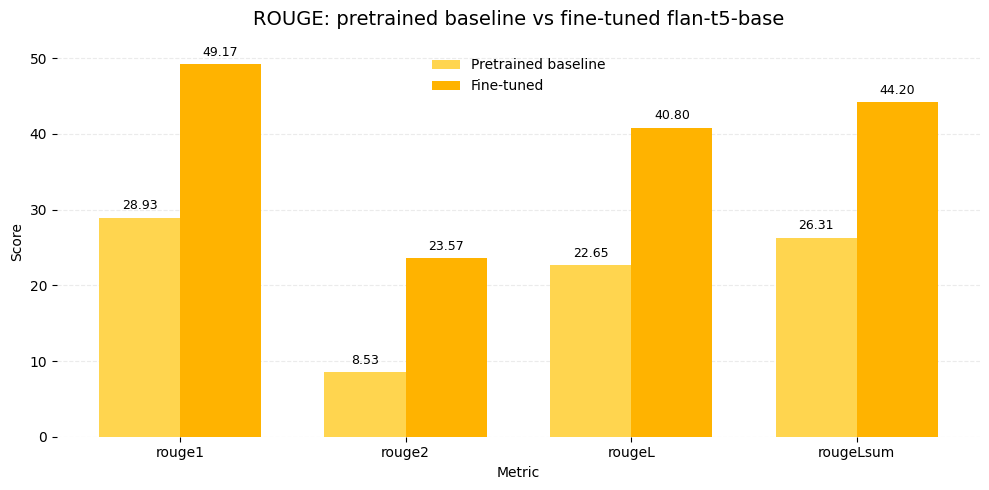

In [23]:
rouge_metrics = metrics_comparison_df[
    metrics_comparison_df["metric"].isin(
        ["rouge1", "rouge2", "rougeL", "rougeLsum"]
    )
].copy()

x = np.arange(len(rouge_metrics))
width = 0.36

fig, ax = plt.subplots(figsize=(10, 5))

baseline_bars = ax.bar(
    x - width / 2,
    rouge_metrics["baseline"],
    width,
    label="Pretrained baseline",
    color="#FFD54F",
)

fine_tuned_bars = ax.bar(
    x + width / 2,
    rouge_metrics["fine_tuned"],
    width,
    label="Fine-tuned",
    color="#FFB300",
)

ax.set_title(
    "ROUGE: pretrained baseline vs fine-tuned flan-t5-base",
    fontsize=14,
    pad=15,
)

ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(rouge_metrics["metric"])
ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.set_axisbelow(True)
ax.legend(frameon=False)

for spine in ax.spines.values():
    spine.set_visible(False)

for bars in [baseline_bars, fine_tuned_bars]:
    for bar in bars:
        ax.annotate(
            f"{bar.get_height():.2f}",
            xy=(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
            ),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
        )

plt.tight_layout()
plt.show()


## Validation predictions


In [24]:
prediction_output = trainer.predict(
    tokenized_dataset["validation"],
    metric_key_prefix="validation",
)

prediction_ids = prediction_output.predictions

if isinstance(prediction_ids, tuple):
    prediction_ids = prediction_ids[0]

prediction_ids = np.asarray(prediction_ids)

if prediction_ids.ndim == 3:
    prediction_ids = np.argmax(
        prediction_ids,
        axis=-1,
    )

prediction_ids = np.where(
    prediction_ids < 0,
    tokenizer.pad_token_id,
    prediction_ids,
).astype(np.int64)

generated_summaries = tokenizer.batch_decode(
    prediction_ids,
    skip_special_tokens=True,
)

validation_results_df = pd.DataFrame({
    "dialogue": experiment_dataset["validation"][DIALOGUE_COL],
    "reference_summary": experiment_dataset["validation"][SUMMARY_COL],
    "generated_summary": generated_summaries,
})

validation_results_df["generated_words"] = (
    validation_results_df["generated_summary"]
    .str.split()
    .str.len()
)

validation_results_df["reference_words"] = (
    validation_results_df["reference_summary"]
    .str.split()
    .str.len()
)

validation_results_df.head()


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


,dialogue,reference_summary,generated_summary,generated_words,reference_words
0,"#Person1#: Hello, how are you doing today?\n#P...",#Person2# has trouble breathing. The doctor as...,#Person2# has been having trouble breathing la...,23,18
1,#Person1#: Hey Jimmy. Let's go workout later t...,#Person1# invites Jimmy to go workout and pers...,Jimmy and #Person1# are going to work out on l...,22,16
2,#Person1#: I need to stop eating such unhealth...,#Person1# plans to stop eating unhealthy foods...,#Person1# wants to stop eating unhealthy foods...,19,15
3,#Person1#: Do you believe in UFOs?\n#Person2#:...,#Person2# believes in UFOs and can see them in...,#Person2# tells #Person1# that #Person2# can s...,25,25
4,#Person1#: Did you go to school today?\n#Perso...,#Person1# didn't go to school today. #Person2#...,#Person1# didn't go to school today. #Person2#...,18,17


In [25]:
for row_index in range(min(5, len(validation_results_df))):
    row = validation_results_df.iloc[row_index]

    print("=" * 90)
    print("DIALOGUE:\n", row["dialogue"])
    print("\nREFERENCE:\n", row["reference_summary"])
    print("\nGENERATED:\n", row["generated_summary"])


DIALOGUE:
 #Person1#: Hello, how are you doing today?
#Person2#: I ' Ve been having trouble breathing lately.
#Person1#: Have you had any type of cold lately?
#Person2#: No, I haven ' t had a cold. I just have a heavy feeling in my chest when I try to breathe.
#Person1#: Do you have any allergies that you know of?
#Person2#: No, I don ' t have any allergies that I know of.
#Person1#: Does this happen all the time or mostly when you are active?
#Person2#: It happens a lot when I work out.
#Person1#: I am going to send you to a pulmonary specialist who can run tests on you for asthma.
#Person2#: Thank you for your help, doctor.

REFERENCE:
 #Person2# has trouble breathing. The doctor asks #Person2# about it and will send #Person2# to a pulmonary specialist.

GENERATED:
 #Person2# has been having trouble breathing lately. #Person1# will send #Person2# to a pulmonary specialist who can run tests on #Person2# for asthma.
DIALOGUE:
 #Person1#: Hey Jimmy. Let's go workout later today.
#Person

## Validation BERTScore


In [26]:
bertscore_metric = evaluate.load("bertscore")

bertscore_results = bertscore_metric.compute(
    predictions=validation_results_df["generated_summary"].tolist(),
    references=validation_results_df["reference_summary"].tolist(),
    model_type="distilbert-base-uncased",
    batch_size=16,
    device="cuda" if torch.cuda.is_available() else "cpu",
)

validation_results_df["bertscore_precision"] = bertscore_results["precision"]
validation_results_df["bertscore_recall"] = bertscore_results["recall"]
validation_results_df["bertscore_f1"] = bertscore_results["f1"]

bertscore_summary = {
    "bertscore_precision": float(
        np.mean(bertscore_results["precision"])
    ),
    "bertscore_recall": float(
        np.mean(bertscore_results["recall"])
    ),
    "bertscore_f1": float(
        np.mean(bertscore_results["f1"])
    ),
}

bertscore_summary


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


{'bertscore_precision': 0.8792868238700279,
 'bertscore_recall': 0.883518060729131,
 'bertscore_f1': 0.8810463735327221}

## Test evaluation


In [27]:
test_metrics = trainer.evaluate(
    eval_dataset=tokenized_dataset["test"],
    metric_key_prefix="test",
)

test_metrics


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Training Loss,Validation Loss,Epoch,Rouge1,Rouge2,Rougel,Rougelsum,Gen Len
8.451766,1.215489,5,44.523400,18.882700,36.204100,39.601800,51.420000


{'test_loss': 1.2154887914657593,
 'test_rouge1': 44.5234,
 'test_rouge2': 18.8827,
 'test_rougeL': 36.2041,
 'test_rougeLsum': 39.6018,
 'test_gen_len': 51.42}

## Test predictions і BERTScore


In [28]:
def clean_prediction_ids(predictions):
    if isinstance(predictions, tuple):
        predictions = predictions[0]

    predictions = np.asarray(predictions)

    if predictions.ndim == 3:
        predictions = np.argmax(
            predictions,
            axis=-1,
        )

    predictions = np.where(
        predictions < 0,
        tokenizer.pad_token_id,
        predictions,
    ).astype(np.int64)

    return predictions


test_prediction_output = trainer.predict(
    tokenized_dataset["test"],
    metric_key_prefix="test_prediction",
)

test_prediction_ids = clean_prediction_ids(
    test_prediction_output.predictions
)

test_generated_summaries = tokenizer.batch_decode(
    test_prediction_ids,
    skip_special_tokens=True,
)

test_results_df = pd.DataFrame({
    "test_index": np.arange(
        len(experiment_dataset["test"])
    ),
    "dialogue": experiment_dataset["test"][DIALOGUE_COL],
    "reference_summary": experiment_dataset["test"][SUMMARY_COL],
    "generated_summary": test_generated_summaries,
})

test_results_df["dialogue_words"] = (
    test_results_df["dialogue"]
    .str.split()
    .str.len()
)

test_results_df["reference_words"] = (
    test_results_df["reference_summary"]
    .str.split()
    .str.len()
)

test_results_df["generated_words"] = (
    test_results_df["generated_summary"]
    .str.split()
    .str.len()
)

test_results_df.head()


,test_index,dialogue,reference_summary,generated_summary,dialogue_words,reference_words,generated_words
0,0,"#Person1#: Ms. Dawson, I need you to take a di...",Ms. Dawson helps #Person1# to write a memo to ...,#Person1# asks Ms. Dawson to take a dictation ...,221,27,38
1,1,"#Person1#: Ms. Dawson, I need you to take a di...",In order to prevent employees from wasting tim...,#Person1# asks Ms. Dawson to take a dictation ...,221,36,38
2,2,"#Person1#: Ms. Dawson, I need you to take a di...",Ms. Dawson takes a dictation for #Person1# abo...,#Person1# asks Ms. Dawson to take a dictation ...,221,27,38
3,3,#Person1#: You're finally here! What took so l...,#Person2# arrives late because of traffic jam....,#Person2# got stuck in traffic again. #Person1...,209,22,34
4,4,#Person1#: You're finally here! What took so l...,#Person2# decides to follow #Person1#'s sugges...,#Person2# got stuck in traffic again. #Person1...,209,18,34


In [29]:
test_bertscore_results = bertscore_metric.compute(
    predictions=test_results_df["generated_summary"].tolist(),
    references=test_results_df["reference_summary"].tolist(),
    model_type="distilbert-base-uncased",
    batch_size=16,
    device="cuda" if torch.cuda.is_available() else "cpu",
)

test_results_df["bertscore_precision"] = (
    test_bertscore_results["precision"]
)
test_results_df["bertscore_recall"] = (
    test_bertscore_results["recall"]
)
test_results_df["bertscore_f1"] = (
    test_bertscore_results["f1"]
)

test_bertscore_summary = {
    "bertscore_precision": float(
        np.mean(test_bertscore_results["precision"])
    ),
    "bertscore_recall": float(
        np.mean(test_bertscore_results["recall"])
    ),
    "bertscore_f1": float(
        np.mean(test_bertscore_results["f1"])
    ),
}

test_bertscore_summary


{'bertscore_precision': 0.8614050962781487,
 'bertscore_recall': 0.8738000433214457,
 'bertscore_f1': 0.8671905707474735}

## Ручне оцінювання (генерація шаблону файлу)


In [30]:
MANUAL_SAMPLE_SIZE = min(
    50,
    len(test_results_df),
)

manual_evaluation_df = (
    test_results_df
    .sample(
        n=MANUAL_SAMPLE_SIZE,
        random_state=SEED,
    )
    .sort_values("test_index")
    .reset_index(drop=True)
    .copy()
)

manual_evaluation_df.insert(
    0,
    "sample_id",
    np.arange(1, len(manual_evaluation_df) + 1),
)

HUMAN_SCORE_COLUMNS = [
    "human_factual_consistency",
    "human_coverage_relevance",
    "human_speaker_attribution",
    "human_fluency_coherence",
    "human_conciseness",
]

for column_name in HUMAN_SCORE_COLUMNS:
    manual_evaluation_df[column_name] = np.nan

manual_evaluation_df["human_comments"] = ""

manual_evaluation_path = (
    RESULTS_DIR
    / f"{EXPERIMENT_NAME}_manual_evaluation_50.csv"
)

manual_evaluation_df.to_csv(
    manual_evaluation_path,
    index=False,
)

print("Шаблон збережено:", manual_evaluation_path)
print("Заповни п'ять колонок оцінками від 1 до 5.")
display(manual_evaluation_df)


Шаблон збережено: /kaggle/working/chatbrief/results/flan_t5_base_full_with_test_manual_evaluation_50.csv
Заповни п'ять колонок оцінками від 1 до 5.


,sample_id,test_index,dialogue,reference_summary,generated_summary,dialogue_words,reference_words,generated_words,bertscore_precision,bertscore_recall,bertscore_f1,human_factual_consistency,human_coverage_relevance,human_speaker_attribution,human_fluency_coherence,human_conciseness,human_comments
0,1,49,#Person1#: Yeah. Just pull on this strip. Then...,#Person1# plans on playing a trick to others. ...,#Person2# tells #Person1# to pull on a strip a...,81,17,22,0.884207,0.866377,0.875201,NaN,NaN,NaN,NaN,NaN,
1,2,51,"#Person1#: What does your sister look like, Mi...",Mike is describing his sister to #Person1#.,Mike tells #Person1# his sister is tall and pr...,46,7,17,0.809725,0.846290,0.827603,NaN,NaN,NaN,NaN,NaN,
2,3,67,"#Person1#: Excuse me.\n#Person2#: Yes, sir. Ca...",#Person2# will change a steak for #Person1# as...,#Person1# asks #Person2# to change the medium-...,84,13,19,0.874726,0.902687,0.888486,NaN,NaN,NaN,NaN,NaN,
3,4,76,#Person1#: Do you drink much?\n#Person2#: Depe...,"#Person2#, a heavy drinker, invites #Person1#,...",#Person2# tells #Person1# that #Person1# drink...,204,25,33,0.851700,0.825341,0.838314,NaN,NaN,NaN,NaN,NaN,
4,5,115,"#Person1#: Maggie, can I borrow your notes for...",Mark asks Maggie for her history notes because...,Mark borrows Maggie's notes for history becaus...,201,22,37,0.776021,0.809325,0.792324,NaN,NaN,NaN,NaN,NaN,
5,6,123,#Person1#: What do you think of this one? \n#P...,#Person1# is showing the new clothes to #Perso...,#Person1# and #Person2# are talking about #Per...,186,20,33,0.853428,0.873084,0.863144,NaN,NaN,NaN,NaN,NaN,
6,7,203,#Person1#: Good evening. Welcome to our restau...,James has reserved a dining room and #Person1#...,James wants a dinning room with a table for ei...,84,16,20,0.894966,0.904869,0.899890,NaN,NaN,NaN,NaN,NaN,
7,8,218,#Person1#: What are you working on?\n#Person2#...,#Person2# introduces the shopping budget which...,#Person2# is figuring out #Person2#'s shopping...,88,17,15,0.896969,0.880011,0.888409,NaN,NaN,NaN,NaN,NaN,
8,9,220,"#Person1#: Where are you going, Jane?\n#Person...",Jane will go to the hospital to visit Susan. H...,Jane is going to the hospital to see Susan. He...,108,18,18,0.917669,0.924234,0.920940,NaN,NaN,NaN,NaN,NaN,
9,10,270,#Person1#: It depends on where you are and wha...,#Person1# hates those who keep smiling at #Per...,#Person2# is fed up with people who keep a str...,103,24,21,0.934292,0.943777,0.939010,NaN,NaN,NaN,NaN,NaN,


In [31]:
print("Manual evaluation file:", manual_evaluation_path)
display(FileLink(str(manual_evaluation_path)))


Manual evaluation file: /kaggle/working/chatbrief/results/flan_t5_base_full_with_test_manual_evaluation_50.csv


/kaggle/working/chatbrief/results/flan_t5_base_full_with_test_manual_evaluation_50.csv

## OpenRouter LLM-as-a-Judge


In [32]:
OPENROUTER_SAMPLE_SIZE = 50
OPENROUTER_MODEL_NAME = "openai/gpt-4.1-mini"
OPENROUTER_API_URL = "https://openrouter.ai/api/v1/chat/completions"

JUDGE_PASS_THRESHOLD = 4
MAX_RETRIES = 4
REQUEST_DELAY_SECONDS = 0.3
OVERWRITE_EXISTING_RESULTS = True

safe_model_name = (
    OPENROUTER_MODEL_NAME
    .replace("/", "_")
    .replace(":", "_")
)

openrouter_results_path = (
    RESULTS_DIR
    / f"{EXPERIMENT_NAME}_openrouter_judge_{safe_model_name}.csv"
)

openrouter_summary_path = (
    RESULTS_DIR
    / f"{EXPERIMENT_NAME}_openrouter_judge_{safe_model_name}_summary.csv"
)

print("Judge model:", OPENROUTER_MODEL_NAME)
print("Results:", openrouter_results_path)


Judge model: openai/gpt-4.1-mini
Results: /kaggle/working/chatbrief/results/flan_t5_base_full_with_test_openrouter_judge_openai_gpt-4.1-mini.csv


In [33]:
OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY", "").strip()
OPENROUTER_KEY_SOURCE = None

if OPENROUTER_API_KEY:
    OPENROUTER_KEY_SOURCE = "environment variable"

if not OPENROUTER_API_KEY:
    try:
        from kaggle_secrets import UserSecretsClient

        secrets_client = UserSecretsClient()
        OPENROUTER_API_KEY = (
            secrets_client
            .get_secret("OPENROUTER_API_KEY")
            .strip()
        )

        if OPENROUTER_API_KEY:
            OPENROUTER_KEY_SOURCE = (
                "Kaggle Secret: OPENROUTER_API_KEY"
            )

    except Exception:
        pass

if not OPENROUTER_API_KEY:
    OPENROUTER_API_KEY = getpass(
        "Введи OpenRouter API key: "
    ).strip()
    OPENROUTER_KEY_SOURCE = "hidden prompt"

if not OPENROUTER_API_KEY:
    raise ValueError("OpenRouter API key не введено.")

print("OpenRouter key source:", OPENROUTER_KEY_SOURCE)


OpenRouter key source: Kaggle Secret: OPENROUTER_API_KEY


In [34]:
judge_sample_df = (
    manual_evaluation_df
    .head(OPENROUTER_SAMPLE_SIZE)
    .copy()
    .reset_index(drop=True)
)

required_columns = [
    "sample_id",
    "test_index",
    "dialogue",
    "reference_summary",
    "generated_summary",
]

missing_columns = [
    column
    for column in required_columns
    if column not in judge_sample_df.columns
]

if missing_columns:
    raise ValueError(f"У таблиці немає колонок: {missing_columns}")

print("Кількість прикладів:", len(judge_sample_df))
display(judge_sample_df[required_columns].head())


Кількість прикладів: 50


,sample_id,test_index,dialogue,reference_summary,generated_summary
0,1,49,#Person1#: Yeah. Just pull on this strip. Then...,#Person1# plans on playing a trick to others. ...,#Person2# tells #Person1# to pull on a strip a...
1,2,51,"#Person1#: What does your sister look like, Mi...",Mike is describing his sister to #Person1#.,Mike tells #Person1# his sister is tall and pr...
2,3,67,"#Person1#: Excuse me.\n#Person2#: Yes, sir. Ca...",#Person2# will change a steak for #Person1# as...,#Person1# asks #Person2# to change the medium-...
3,4,76,#Person1#: Do you drink much?\n#Person2#: Depe...,"#Person2#, a heavy drinker, invites #Person1#,...",#Person2# tells #Person1# that #Person1# drink...
4,5,115,"#Person1#: Maggie, can I borrow your notes for...",Mark asks Maggie for her history notes because...,Mark borrows Maggie's notes for history becaus...


In [35]:
JUDGE_CRITERIA = [
    "factual_consistency",
    "coverage_relevance",
    "speaker_attribution",
    "fluency_coherence",
    "conciseness",
]

criterion_schema = {
    "type": "object",
    "properties": {
        "score": {
            "type": "integer",
            "minimum": 1,
            "maximum": 5,
        },
        "reason": {
            "type": "string",
        },
    },
    "required": ["score", "reason"],
    "additionalProperties": False,
}

JUDGE_RESPONSE_SCHEMA = {
    "type": "object",
    "properties": {
        **{
            criterion: criterion_schema
            for criterion in JUDGE_CRITERIA
        },
        "overall_comment": {
            "type": "string",
        },
    },
    "required": [
        *JUDGE_CRITERIA,
        "overall_comment",
    ],
    "additionalProperties": False,
}


def validate_judge_response(evaluation):
    if not isinstance(evaluation, dict):
        raise ValueError("Judge response має бути JSON object.")

    for criterion in JUDGE_CRITERIA:
        result = evaluation.get(criterion)

        if not isinstance(result, dict):
            raise ValueError(f"Немає результату для {criterion}.")

        score = result.get("score")
        reason = result.get("reason")

        if (
            not isinstance(score, int)
            or isinstance(score, bool)
            or not 1 <= score <= 5
        ):
            raise ValueError(
                f"Некоректний score для {criterion}: {score}"
            )

        if not isinstance(reason, str) or not reason.strip():
            raise ValueError(f"Немає reason для {criterion}.")

    if not isinstance(evaluation.get("overall_comment"), str):
        raise ValueError("Немає overall_comment.")


In [36]:
SYSTEM_PROMPT = """
You are an expert evaluator of dialogue summarization systems.

Your task is to evaluate a GENERATED SUMMARY of an ORIGINAL DIALOGUE.

The ORIGINAL DIALOGUE is the primary source of truth.
The REFERENCE SUMMARY is only an additional guide to the important
content. A generated summary may use different wording and still be
fully correct.

Evaluate the generated summary independently according to exactly
five criteria.

Use only integer scores from 1 to 5.

GENERAL SCORING SCALE

1 = Very poor
The summary has a serious failure for this criterion and is
unreliable or unusable.

2 = Poor
The summary has one or more major problems that significantly
reduce its quality.

3 = Acceptable
The main idea is understandable, but there are noticeable
problems, errors or omissions.

4 = Good
The summary satisfies the criterion. There may be one minor issue,
but it does not change the central meaning.

5 = Excellent
The summary fully satisfies the criterion and has no meaningful
problems.

CRITERION 1: FACTUAL CONSISTENCY

Check whether every claim in the generated summary is supported
by the original dialogue.

Penalize:
- invented or unsupported facts;
- contradictions with the dialogue;
- incorrect actions, decisions, dates, numbers or relationships;
- incorrect descriptions of intentions or emotions;
- claims that exaggerate or change the original meaning.

Do not penalize valid paraphrasing.

Score 5 only when every factual claim is supported by the dialogue.
Score 4 when there is at most one very minor imprecision that does
not change the main meaning.

CRITERION 2: COVERAGE AND RELEVANCE

Check whether the generated summary captures:
- the central topic;
- important actions;
- important decisions;
- intentions and reasons;
- the final result or outcome, when present.

Penalize:
- omission of important events, decisions or outcomes;
- focusing on secondary details instead of the main point;
- inclusion of irrelevant information;
- a summary that is too vague to represent the conversation.

Do not require the generated summary to copy the wording of the
reference summary.

Score 5 when all essential information is included without
irrelevant details.
Score 4 when the central content is covered with at most one
minor omission.

CRITERION 3: SPEAKER ATTRIBUTION

Check whether actions, statements, opinions, intentions, decisions
and emotions are attributed to the correct speakers.

Penalize:
- assigning one speaker's statement or action to another;
- changing who proposed, wanted or decided something;
- incorrectly merging the intentions of different speakers;
- saying that both speakers agreed when the dialogue does not
  support that conclusion.

Do not penalize neutral plural wording when the dialogue clearly
supports a joint action or decision.

When the generated summary contains no explicit speaker
attribution, do not invent an attribution error.

Score 5 when every attribution is correct.
Score 4 when there is at most a minor ambiguity that does not
change the meaning.

CRITERION 4: FLUENCY AND COHERENCE

Evaluate:
- grammar;
- sentence completeness;
- natural wording;
- readability;
- logical connection between ideas;
- whether the summary is understandable as a standalone text.

Penalize:
- sentence fragments;
- confusing or unnatural wording;
- grammar errors;
- contradictions inside the summary;
- awkward repetition.

Score 5 when the summary is natural, grammatical and coherent.
Score 4 when it is clear and readable with at most one minor
language issue.

CRITERION 5: CONCISENESS

Check whether the summary is concise while preserving the
essential meaning of the dialogue.

Penalize:
- repetition;
- greetings and conversational filler;
- unnecessary examples or secondary details;
- excessive verbosity;
- extreme brevity that removes the central topic, decision
  or outcome.

Score 5 when the summary is compact, focused and complete.
Score 4 when its length is appropriate with at most a small amount
of unnecessary detail.

IMPORTANT RULES

- Evaluate each criterion separately.
- Return integer scores only: 1, 2, 3, 4 or 5.
- Do not use decimal scores.
- Do not use a 0–1 scale.
- Do not use a 0–10 scale.
- Do not calculate an overall numeric score.
- Do not reward the generated summary merely for copying words
  from the reference.
- Do not penalize accurate paraphrasing.
- Reasons must be short and based on concrete evidence from the
  dialogue and generated summary.
""".strip()

In [37]:
def evaluate_summary_with_openrouter(
    dialogue,
    reference_summary,
    generated_summary,
):
    user_prompt = f"""
ORIGINAL DIALOGUE:
<dialogue>
{dialogue}
</dialogue>

REFERENCE SUMMARY:
<reference_summary>
{reference_summary}
</reference_summary>

GENERATED SUMMARY:
<generated_summary>
{generated_summary}
</generated_summary>

Evaluate the GENERATED SUMMARY according to all five criteria.
Return the result using the required JSON schema.
""".strip()

    request_body = {
        "model": OPENROUTER_MODEL_NAME,
        "messages": [
            {
                "role": "system",
                "content": SYSTEM_PROMPT,
            },
            {
                "role": "user",
                "content": user_prompt,
            },
        ],
        "temperature": 0,
        "max_completion_tokens": 1200,
        "response_format": {
            "type": "json_schema",
            "json_schema": {
                "name": "summary_evaluation",
                "strict": True,
                "schema": JUDGE_RESPONSE_SCHEMA,
            },
        },
        "provider": {
            "require_parameters": True,
        },
    }

    headers = {
        "Authorization": (
            f"Bearer {OPENROUTER_API_KEY}"
        ),
        "Content-Type": "application/json",
    }

    last_error = None

    for attempt in range(1, MAX_RETRIES + 1):
        try:
            response = requests.post(
                OPENROUTER_API_URL,
                headers=headers,
                json=request_body,
                timeout=120,
            )

            if response.status_code == 429:
                wait_seconds = 2 ** attempt

                print(
                    "Rate limit. Повтор через",
                    wait_seconds,
                    "секунд..."
                )

                time.sleep(wait_seconds)
                continue

            if response.status_code >= 500:
                wait_seconds = 2 ** attempt

                print(
                    "Тимчасова помилка сервера",
                    response.status_code,
                    "- повтор через",
                    wait_seconds,
                    "секунд..."
                )

                time.sleep(wait_seconds)
                continue

            if not response.ok:
                raise RuntimeError(
                    "OpenRouter API error "
                    f"{response.status_code}: "
                    f"{response.text}"
                )

            response_json = response.json()

            if not response_json.get("choices"):
                raise RuntimeError(
                    "OpenRouter не повернув choices: "
                    f"{response_json}"
                )

            message = (
                response_json["choices"][0]["message"]
            )

            content = message.get("content")

            if not content:
                raise RuntimeError(
                    "Judge повернув порожню відповідь."
                )

            if isinstance(content, dict):
                evaluation = content
            else:
                evaluation = json.loads(content)

            validate_judge_response(
                evaluation
            )

            usage = response_json.get(
                "usage",
                {},
            )

            metadata = {
                "openrouter_response_id": (
                    response_json.get("id")
                ),
                "returned_model": (
                    response_json.get("model")
                ),
                "prompt_tokens": usage.get(
                    "prompt_tokens"
                ),
                "completion_tokens": usage.get(
                    "completion_tokens"
                ),
                "total_tokens": usage.get(
                    "total_tokens"
                ),
            }

            return evaluation, metadata

        except (
            requests.RequestException,
            json.JSONDecodeError,
            RuntimeError,
            ValueError,
        ) as error:
            last_error = error

            if attempt < MAX_RETRIES:
                wait_seconds = 2 ** attempt

                print(
                    f"Спроба {attempt} невдала:",
                    str(error)[:300],
                )

                print(
                    "Повтор через",
                    wait_seconds,
                    "секунд..."
                )

                time.sleep(wait_seconds)

    raise RuntimeError(
        "Не вдалося отримати коректну оцінку "
        f"після {MAX_RETRIES} спроб. "
        f"Остання помилка: {last_error}"
    )

In [38]:
if (
    OVERWRITE_EXISTING_RESULTS
    and openrouter_results_path.exists()
):
    openrouter_results_path.unlink()

    print(
        "Старий файл видалено:",
        openrouter_results_path,
    )


judge_rows = []

for row_number, row in (
    judge_sample_df.iterrows()
):
    print(
        f"Evaluating "
        f"{row_number + 1}/"
        f"{len(judge_sample_df)}..."
    )

    result_row = {
        "sample_id": int(row["sample_id"]),
        "test_index": int(row["test_index"]),
        "judge_model": (
            OPENROUTER_MODEL_NAME
        ),
        "dialogue": row["dialogue"],
        "reference_summary": (
            row["reference_summary"]
        ),
        "generated_summary": (
            row["generated_summary"]
        ),
    }

    try:
        evaluation, metadata = (
            evaluate_summary_with_openrouter(
                dialogue=row["dialogue"],
                reference_summary=(
                    row["reference_summary"]
                ),
                generated_summary=(
                    row["generated_summary"]
                ),
            )
        )

        criterion_scores = []

        for criterion in JUDGE_CRITERIA:
            score = int(
                evaluation[criterion]["score"]
            )

            reason = (
                evaluation[criterion]["reason"]
            )

            result_row[
                f"judge_{criterion}_score"
            ] = score

            result_row[
                f"judge_{criterion}_passed"
            ] = (
                score
                >= JUDGE_PASS_THRESHOLD
            )

            result_row[
                f"judge_{criterion}_reason"
            ] = reason

            criterion_scores.append(score)

        result_row[
            "judge_mean_score_1_to_5"
        ] = float(
            np.mean(criterion_scores)
        )

        result_row[
            "judge_overall_passed"
        ] = all(
            score >= JUDGE_PASS_THRESHOLD
            for score in criterion_scores
        )

        result_row[
            "judge_overall_comment"
        ] = evaluation["overall_comment"]

        result_row.update(metadata)

        result_row["evaluation_error"] = ""

    except Exception as error:
        print(
            "Помилка на sample_id",
            row["sample_id"],
            ":",
            error,
        )

        for criterion in JUDGE_CRITERIA:
            result_row[
                f"judge_{criterion}_score"
            ] = np.nan

            result_row[
                f"judge_{criterion}_passed"
            ] = False

            result_row[
                f"judge_{criterion}_reason"
            ] = ""

        result_row[
            "judge_mean_score_1_to_5"
        ] = np.nan

        result_row[
            "judge_overall_passed"
        ] = False

        result_row[
            "judge_overall_comment"
        ] = ""

        result_row[
            "evaluation_error"
        ] = (
            f"{type(error).__name__}: {error}"
        )

    judge_rows.append(result_row)

    openrouter_results_df = pd.DataFrame(
        judge_rows
    )

    openrouter_results_df.to_csv(
        openrouter_results_path,
        index=False,
    )

    time.sleep(REQUEST_DELAY_SECONDS)


print(
    "Оцінювання завершено:",
    openrouter_results_path,
)

display(openrouter_results_df.head())


Evaluating 1/50...
Evaluating 2/50...
Evaluating 3/50...
Evaluating 4/50...
Evaluating 5/50...
Evaluating 6/50...
Evaluating 7/50...
Evaluating 8/50...
Evaluating 9/50...
Evaluating 10/50...
Evaluating 11/50...
Evaluating 12/50...
Evaluating 13/50...
Evaluating 14/50...
Evaluating 15/50...
Evaluating 16/50...
Evaluating 17/50...
Evaluating 18/50...
Evaluating 19/50...
Evaluating 20/50...
Evaluating 21/50...
Evaluating 22/50...
Evaluating 23/50...
Evaluating 24/50...
Evaluating 25/50...
Evaluating 26/50...
Evaluating 27/50...
Evaluating 28/50...
Evaluating 29/50...
Evaluating 30/50...
Evaluating 31/50...
Evaluating 32/50...
Evaluating 33/50...
Evaluating 34/50...
Evaluating 35/50...
Evaluating 36/50...
Evaluating 37/50...
Evaluating 38/50...
Evaluating 39/50...
Evaluating 40/50...
Evaluating 41/50...
Evaluating 42/50...
Evaluating 43/50...
Evaluating 44/50...
Evaluating 45/50...
Evaluating 46/50...
Evaluating 47/50...
Evaluating 48/50...
Evaluating 49/50...
Evaluating 50/50...
Оцінюванн

,sample_id,test_index,judge_model,dialogue,reference_summary,generated_summary,judge_factual_consistency_score,judge_factual_consistency_passed,judge_factual_consistency_reason,judge_coverage_relevance_score,...,judge_conciseness_reason,judge_mean_score_1_to_5,judge_overall_passed,judge_overall_comment,openrouter_response_id,returned_model,prompt_tokens,completion_tokens,total_tokens,evaluation_error
0,1,49,openai/gpt-4.1-mini,#Person1#: Yeah. Just pull on this strip. Then...,#Person1# plans on playing a trick to others. ...,#Person2# tells #Person1# to pull on a strip a...,2,False,The summary incorrectly attributes the instruc...,3,...,The summary is concise and focused without unn...,3.2,False,The generated summary is concise and mostly cl...,gen-1786456299-xVZ1BORxR8Z5GvD5hPK7,openai/gpt-4.1-mini,1329,249,1578,
1,2,51,openai/gpt-4.1-mini,"#Person1#: What does your sister look like, Mi...",Mike is describing his sister to #Person1#.,Mike tells #Person1# his sister is tall and pr...,3,False,The summary correctly states Mike's descriptio...,4,...,"The summary is concise and focused, without un...",4.0,False,The summary captures the main descriptive poin...,gen-1786456306-GrXPqx8CBn9eA2VpFNhw,openai/gpt-4.1-mini,1265,237,1502,
2,3,67,openai/gpt-4.1-mini,"#Person1#: Excuse me.\n#Person2#: Yes, sir. Ca...",#Person2# will change a steak for #Person1# as...,#Person1# asks #Person2# to change the medium-...,5,True,The summary accurately reflects the dialogue's...,4,...,"The summary is concise and focused, including ...",4.8,True,"The generated summary is factually accurate, c...",gen-1786456311-XwIi5kYujAirMPT9bEi9,openai/gpt-4.1-mini,1337,211,1548,
3,4,76,openai/gpt-4.1-mini,#Person1#: Do you drink much?\n#Person2#: Depe...,"#Person2#, a heavy drinker, invites #Person1#,...",#Person2# tells #Person1# that #Person1# drink...,2,False,The summary incorrectly states that Person2 te...,2,...,The summary is relatively concise but includes...,2.6,False,The generated summary contains significant fac...,gen-1786456314-y2mPBxGiR7VXwCaEKFx9,openai/gpt-4.1-mini,1546,279,1825,
4,5,115,openai/gpt-4.1-mini,"#Person1#: Maggie, can I borrow your notes for...",Mark asks Maggie for her history notes because...,Mark borrows Maggie's notes for history becaus...,3,False,The summary correctly states Mark borrows Magg...,3,...,The summary is concise and focused without unn...,3.6,False,The summary captures some key points but conta...,gen-1786456319-ETCWW1jqRGLqAGIhajxC,openai/gpt-4.1-mini,1502,229,1731,


## Training history


In [39]:
history_df = pd.DataFrame(
    trainer.state.log_history
)

history_df


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_rouge1,eval_rouge2,eval_rougeL,eval_rougeLsum,...,final_steps_per_second,test_loss,test_rouge1,test_rouge2,test_rougeL,test_rougeLsum,test_gen_len,test_runtime,test_samples_per_second,test_steps_per_second
0,15.597257,46.857811,1.846154e-06,0.032103,25,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,13.828531,23.085953,3.769231e-06,0.064205,50,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,12.146536,19.153708,5.692308e-06,0.096308,75,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,12.176835,17.988911,7.615385e-06,0.128411,100,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,11.483655,18.246811,9.538462e-06,0.160514,125,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
158,8.451766,11.771896,1.797432e-07,4.974639,3875,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
159,NaN,NaN,NaN,5.000000,3895,0.983804,48.9483,23.42,40.6825,44.0925,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
160,NaN,NaN,NaN,5.000000,3895,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
161,NaN,NaN,NaN,5.000000,3895,NaN,NaN,NaN,NaN,NaN,...,0.552,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


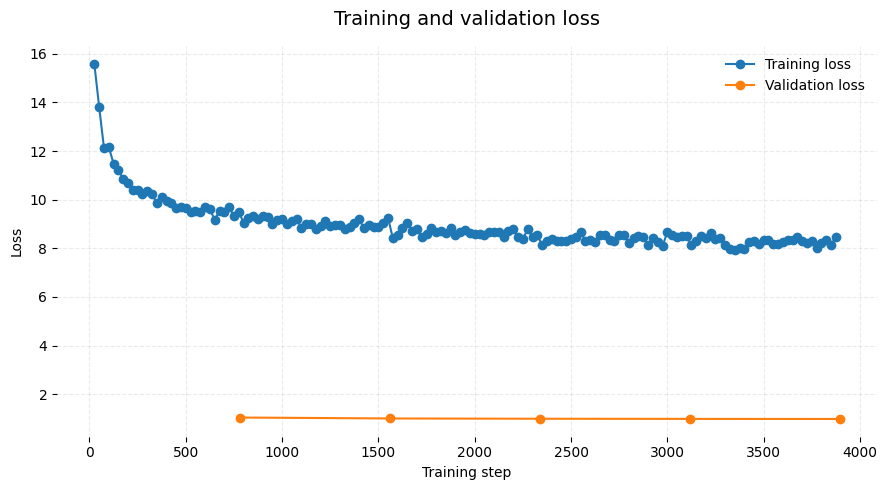

In [40]:
train_history = history_df.dropna(
    subset=["loss"],
    how="any",
)

eval_history = history_df.dropna(
    subset=["eval_loss"],
    how="any",
)

fig, ax = plt.subplots(figsize=(9, 5))

if not train_history.empty:
    ax.plot(
        train_history["step"],
        train_history["loss"],
        marker="o",
        label="Training loss",
    )

if not eval_history.empty:
    ax.plot(
        eval_history["step"],
        eval_history["eval_loss"],
        marker="o",
        label="Validation loss",
    )

ax.set_title(
    "Training and validation loss",
    fontsize=14,
    pad=15,
)

ax.set_xlabel("Training step")
ax.set_ylabel("Loss")
ax.grid(linestyle="--", alpha=0.25)
ax.set_axisbelow(True)
ax.legend(frameon=False)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()


## Збереження результатів


In [41]:
trainer.save_model(str(FINAL_MODEL_DIR))
tokenizer.save_pretrained(str(FINAL_MODEL_DIR))

validation_results_path = (
    RESULTS_DIR
    / f"{EXPERIMENT_NAME}_validation_predictions.csv"
)
test_results_path = (
    RESULTS_DIR
    / f"{EXPERIMENT_NAME}_test_predictions.csv"
)
history_path = (
    RESULTS_DIR
    / f"{EXPERIMENT_NAME}_training_history.csv"
)
metrics_path = (
    RESULTS_DIR
    / f"{EXPERIMENT_NAME}_metrics.json"
)

validation_results_df.to_csv(validation_results_path, index=False)
test_results_df.to_csv(test_results_path, index=False)
history_df.to_csv(history_path, index=False)

all_metrics = {
    "configuration": {
        "model_name": MODEL_NAME,
        "experiment_name": EXPERIMENT_NAME,
        "train_size": len(experiment_dataset["train"]),
        "validation_size": len(experiment_dataset["validation"]),
        "test_size": len(experiment_dataset["test"]),
        "epochs": NUM_EPOCHS,
        "learning_rate": LEARNING_RATE,
        "train_batch_size": TRAIN_BATCH_SIZE,
        "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
        "max_input_length": MAX_INPUT_LENGTH,
        "max_target_length": MAX_TARGET_LENGTH,
        "seed": SEED,
    },
    "baseline_metrics": globals().get("baseline_metrics"),
    "validation_metrics": globals().get("final_metrics"),
    "validation_bertscore": globals().get("bertscore_summary"),
    "test_metrics": globals().get("test_metrics"),
    "test_bertscore": globals().get("test_bertscore_summary"),
    "best_checkpoint": getattr(trainer.state, "best_model_checkpoint", None),
    "human_quality_pass_rate": globals().get(
        "human_quality_pass_rate"
    ),
    "openrouter_judge_model": globals().get(
        "OPENROUTER_MODEL_NAME"
    ),
    "openrouter_quality_pass_rate": globals().get(
        "openrouter_quality_pass_rate"
    ),
    "openrouter_average_score": globals().get(
        "openrouter_average_score"
    ),
}

with open(metrics_path, "w", encoding="utf-8") as file:
    json.dump(
        all_metrics,
        file,
        indent=2,
        ensure_ascii=False,
        default=str,
    )

print("Model:", FINAL_MODEL_DIR)
print("Validation predictions:", validation_results_path)
print("Test predictions:", test_results_path)
print("Manual evaluation template:", manual_evaluation_path)
print("Metrics:", metrics_path)
print("History:", history_path)

if "openrouter_results_path" in globals():
    print("OpenRouter results:", openrouter_results_path)

if "openrouter_summary_path" in globals():
    print("OpenRouter summary:", openrouter_summary_path)


# Persist evaluation outputs too, so a later Kaggle session reset cannot erase them.
hub_api.upload_folder(
    folder_path=str(RESULTS_DIR),
    path_in_repo="results",
    repo_id=HUB_REPO_ID,
    commit_message="Save evaluation results",
)

print("Results also uploaded to private Hub repo:", HUB_REPO_ID)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

No files have been modified since last commit. Skipping to prevent empty commit.


Model: /kaggle/working/chatbrief/models/flan_t5_base_full_with_test_best
Validation predictions: /kaggle/working/chatbrief/results/flan_t5_base_full_with_test_validation_predictions.csv
Test predictions: /kaggle/working/chatbrief/results/flan_t5_base_full_with_test_test_predictions.csv
Manual evaluation template: /kaggle/working/chatbrief/results/flan_t5_base_full_with_test_manual_evaluation_50.csv
Metrics: /kaggle/working/chatbrief/results/flan_t5_base_full_with_test_metrics.json
History: /kaggle/working/chatbrief/results/flan_t5_base_full_with_test_training_history.csv
OpenRouter results: /kaggle/working/chatbrief/results/flan_t5_base_full_with_test_openrouter_judge_openai_gpt-4.1-mini.csv
OpenRouter summary: /kaggle/working/chatbrief/results/flan_t5_base_full_with_test_openrouter_judge_openai_gpt-4.1-mini_summary.csv
Results also uploaded to private Hub repo: olenkahnyp/flan_t5_base_full_with_test-recovery


## Архів результатів


In [42]:
archive_base = str(
    KAGGLE_WORKING_DIR / f"{EXPERIMENT_NAME}_experiment"
)

archive_path = shutil.make_archive(
    archive_base,
    "zip",
    root_dir=PROJECT_DIR,
)

print("Archive:", archive_path)


Archive: /kaggle/working/flan_t5_base_full_with_test_experiment.zip


In [43]:
print("Kaggle output archive:")
display(FileLink(archive_path))


Kaggle output archive:


/kaggle/working/flan_t5_base_full_with_test_experiment.zip